In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/raw/loan.csv")

df.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/loan.csv'

In [3]:
import os

print(os.getcwd())

h:\school-of-ai-data-science-internship\01-projects\04-loan-default-risk\notebooks


In [4]:
df = pd.read_csv("../data/raw/loan.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB

Missing Values:

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education    

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [7]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": 0, "N": 1})

df["Loan_Status"].value_counts()

Loan_Status
0    422
1    192
Name: count, dtype: int64

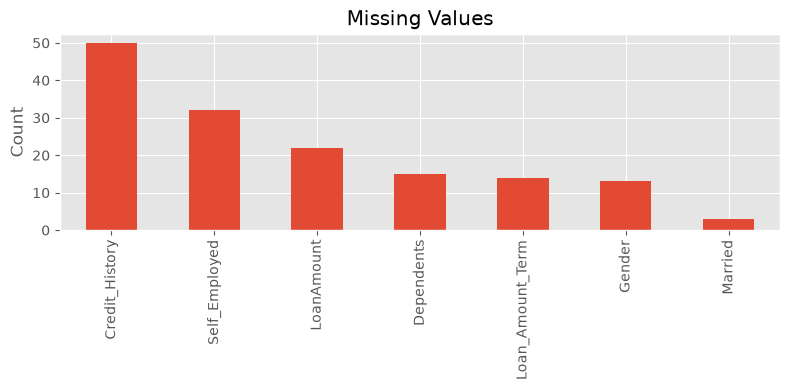

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
missing[missing > 0].plot(kind="bar")
plt.title("Missing Values")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/missing_values.png")

plt.show()

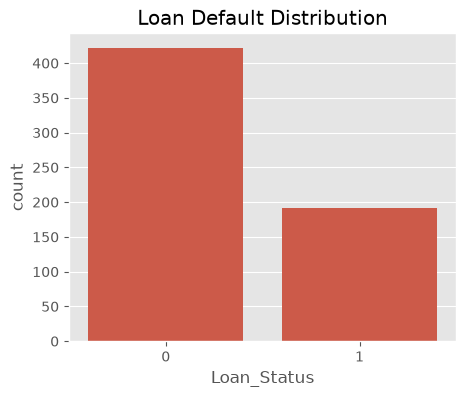

Loan_Status
0    0.687296
1    0.312704
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="Loan_Status")

plt.title("Loan Default Distribution")

plt.savefig("../reports/figures/default_rate.png")

plt.show()

print(df["Loan_Status"].value_counts(normalize=True))

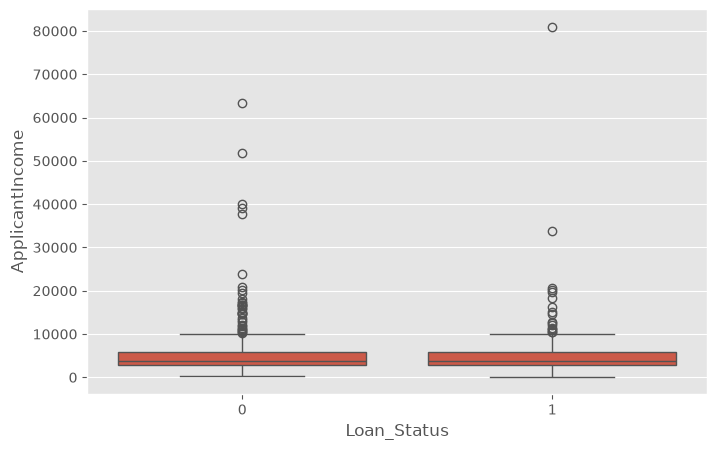

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="ApplicantIncome"
)

plt.savefig("../reports/figures/applicant_income.png")

plt.show()

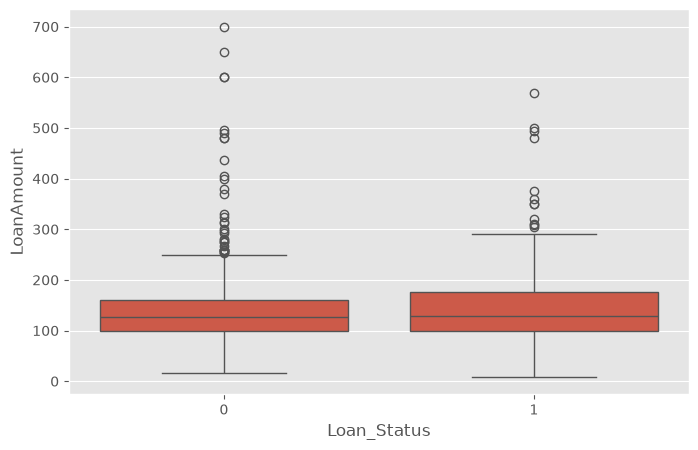

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="LoanAmount"
)

plt.savefig("../reports/figures/loan_amount.png")

plt.show()

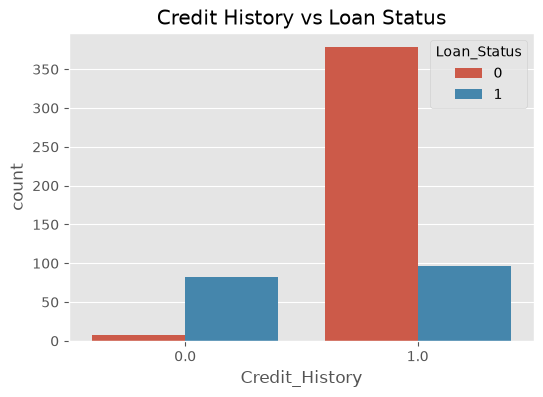

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Credit History vs Loan Status")

plt.savefig("../reports/figures/credit_history.png")

plt.show()

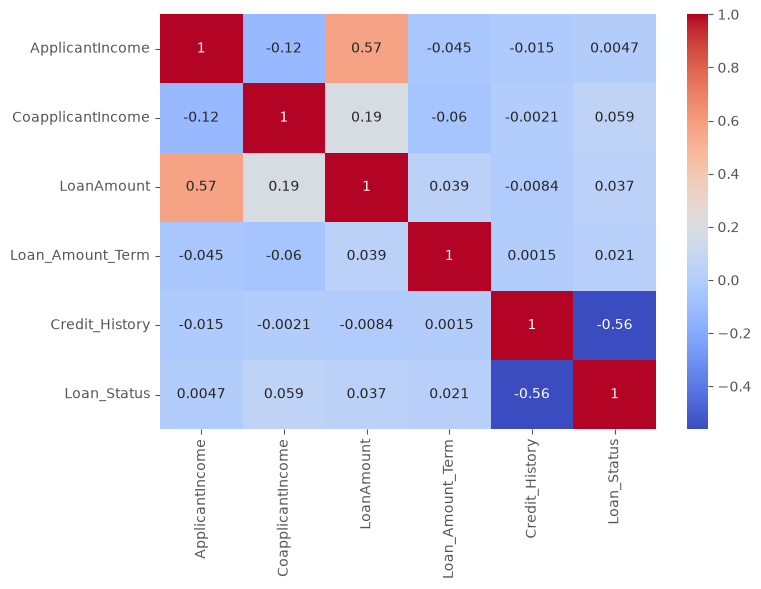

In [13]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.tight_layout()

plt.savefig("../reports/figures/correlation_heatmap.png")

plt.show()

## EDA Insights

- Applicants with poor or missing credit history have a higher loan default risk.

- Higher loan amounts generally show a greater chance of default.

- Applicant income alone is not a perfect predictor of loan default.

- The dataset contains missing values in Gender, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History, which will be handled during preprocessing.

- Credit History appears to be one of the strongest predictors of loan approval/default.